# Section 1: Exploratory Data Analysis (EDA)
This notebook performs Exploratory Data Analysis on two real-world datasets:
1. **Titanic Survival Data**: Focus on missing data and multivariate analysis.
2. **Lending Club Loan Data**: Focus on loan status, interest rates, and grade distributions.

Datasets are imported from [OpenML.org](https://OpenML.org), a public repository for machine learning data.
sklearn has multiple datasets which can be loaded from scikitlearn.datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Load Titanic Dataset from OpenML
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML
print('Fetching LendingClub dataset from OpenML...')
# Using a common OpenML version of lending club
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## 1. Titanic
### Data overview

In [3]:
print(titanic_df.shape)
display(titanic_df.head())
print(titanic_df.info())
display(titanic_df.describe())
display(titanic_df.describe(include='object'))

(1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 116.5 KB
None


,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


C:\Users\samik\AppData\Local\Temp\ipykernel_16468\569345971.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(titanic_df.describe(include='object'))


,name,ticket,cabin,boat,home.dest
count,1309,1309,295,486,745
unique,1307,929,186,27,369
top,"Connolly, Miss. Kate",CA. 2343,C23 C25 C27,13,"New York, NY"
freq,2,11,6,39,64


### Target Variable Analysis

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

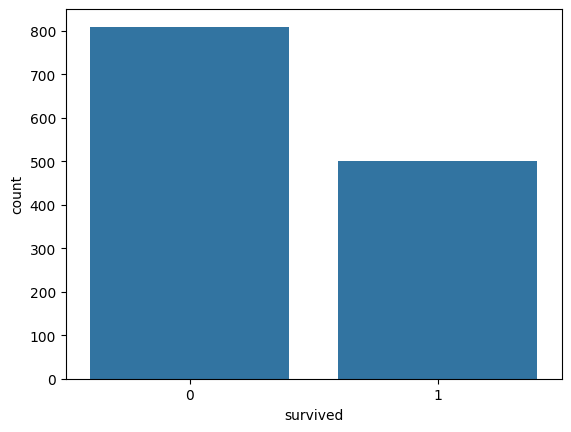

In [4]:
sns.countplot(x='survived', data=titanic_df)
titanic_df['survived'].value_counts(normalize=True)

### Missing values and Duplicates

In [5]:
# Missing values for all variables in Titanic dataset
print("--- Titanic Missing Values ---")
print(titanic_df.isnull().sum().sort_values(ascending=False))

titanic_df.duplicated().sum()


--- Titanic Missing Values ---
body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
sibsp           0
name            0
survived        0
pclass          0
sex             0
parch           0
ticket          0
dtype: int64


np.int64(0)

<Axes: xlabel='age_missing', ylabel='survived'>

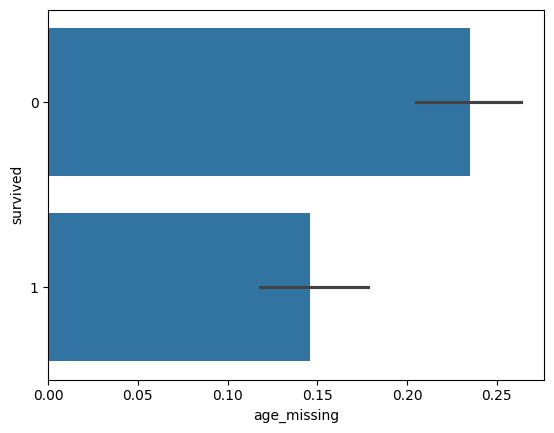

In [6]:
titanic_df['age_missing'] = titanic_df['age'].isnull()

sns.barplot(x='age_missing', y='survived', data=titanic_df)

### Univariate analysis
#### Numerical features

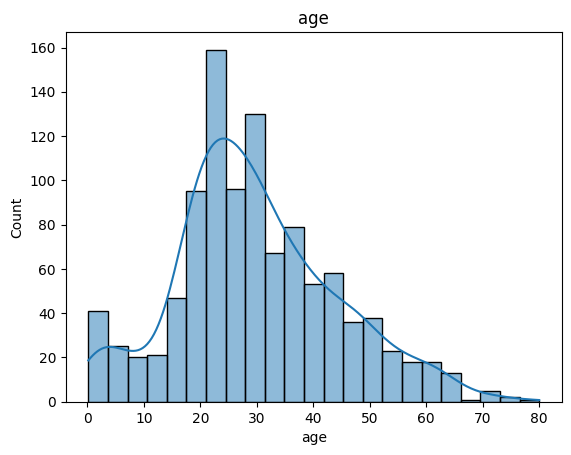

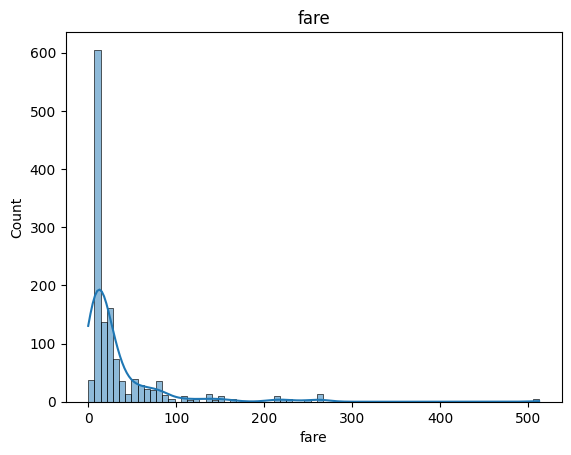

In [14]:
target_cols1 = ['age', 'fare']

num_cols_titanic = titanic_df[target_cols1]

for col in num_cols_titanic:
    plt.figure()
    sns.histplot(titanic_df[col], kde=True)
    plt.title(col)

### Univariate analysis
#### Categorical features

In [15]:
# Value counts for specific categorical columns using Top 5 logic for all
target_cols = ['survived', 'sex', 'embarked', 'home.dest','pclass']

for col in target_cols:
    print(f"--- Analysis for {col} ---")
    counts = titanic_df[col].value_counts(dropna=True, normalize=True)

    if len(counts) > 5:
        top_5 = counts.nlargest(5)
        others_count = counts.iloc[5:].sum()
        res = pd.concat([top_5, pd.Series({'Others': others_count})])
        print("Top Counts:")
        print(res)
    else:
        print("Counts:")
        print(counts)
    print("\n")

--- Analysis for survived ---
Counts:
survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64


--- Analysis for sex ---
Counts:
sex
male      0.644003
female    0.355997
Name: proportion, dtype: float64


--- Analysis for embarked ---
Counts:
embarked
S    0.699311
C    0.206580
Q    0.094109
Name: proportion, dtype: float64


--- Analysis for home.dest ---
Top Counts:
New York, NY            0.085906
London                  0.018792
Montreal, PQ            0.013423
Paris, France           0.012081
Cornwall / Akron, OH    0.012081
Others                  0.857718
dtype: float64


--- Analysis for pclass ---
Counts:
pclass
3    0.541635
1    0.246753
2    0.211612
Name: proportion, dtype: float64




### Outlier Detection

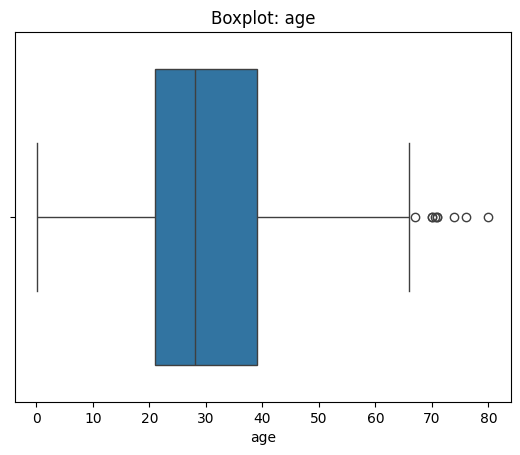

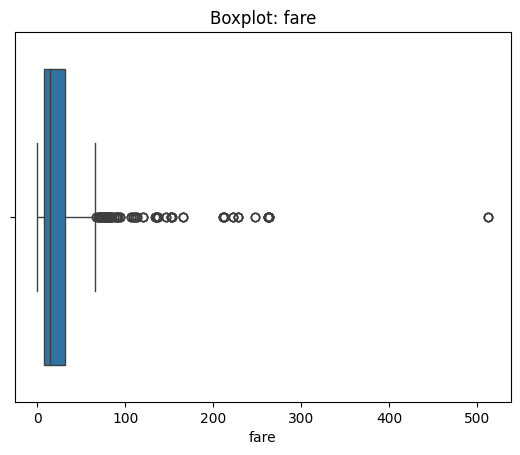

In [16]:
for col in num_cols_titanic:
    plt.figure()
    sns.boxplot(x=titanic_df[col])
    plt.title(f"Boxplot: {col}")

### Multivariate analysis


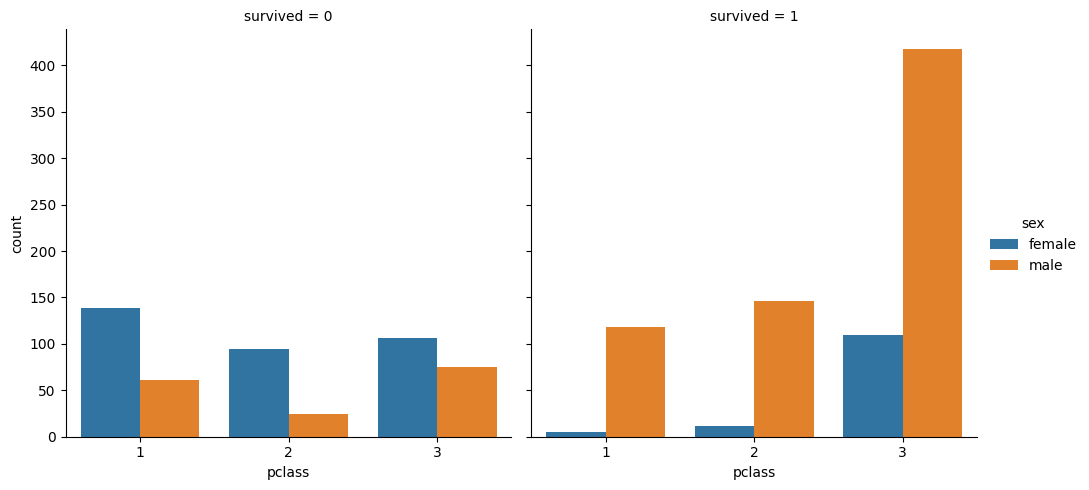

In [17]:
sns.catplot(x='pclass', hue='sex', col='survived',
            data=titanic_df, kind='count')

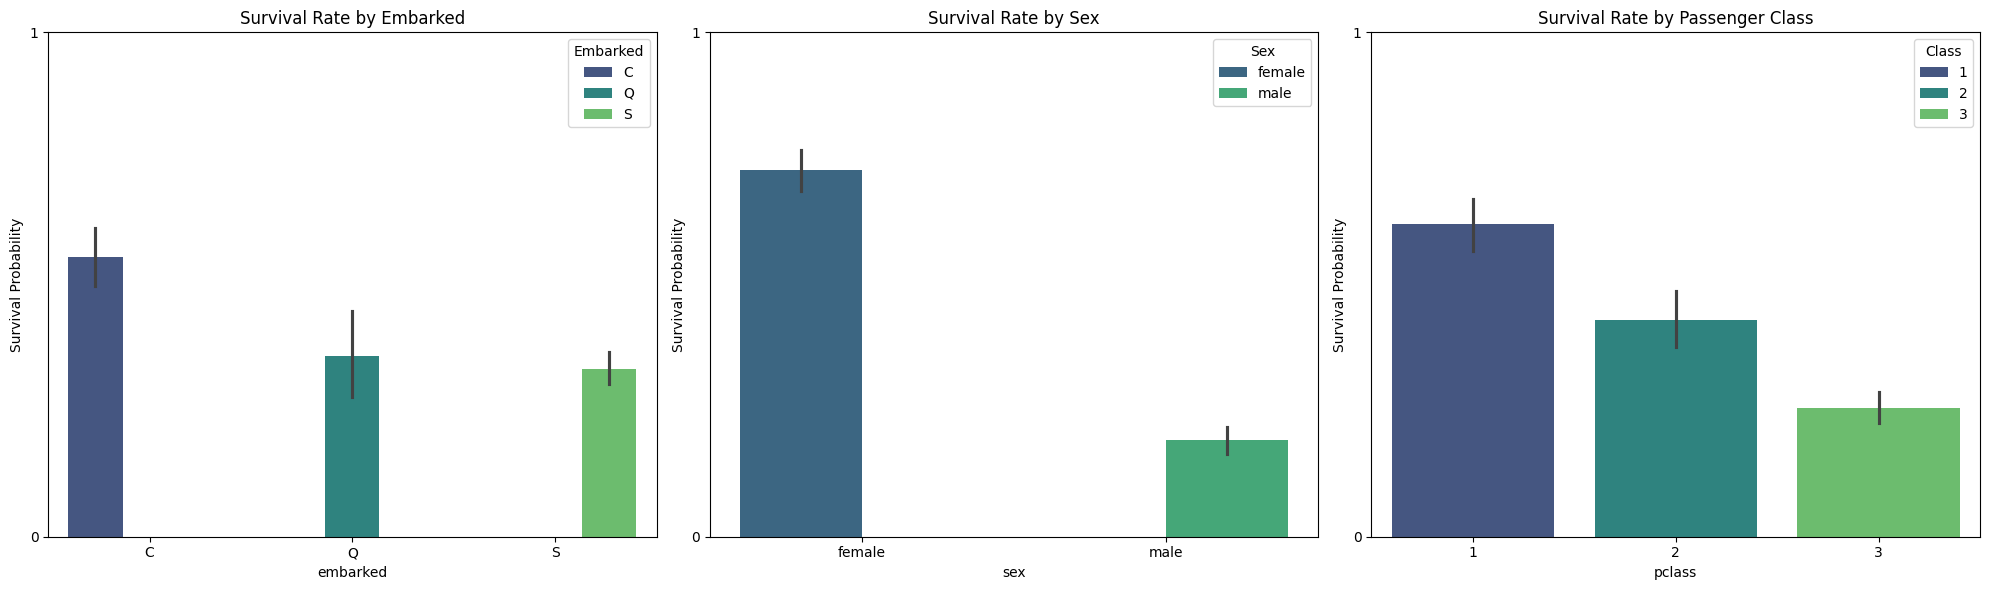

In [19]:
# Ensure pclass is categorical (string)
titanic_df['pclass'] = titanic_df['pclass'].astype(str)

# Standardizing palette and layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Survival Rate by Embarked
sns.barplot(data=titanic_df, x='embarked', y='survived', ax=axes[0], palette='viridis', hue='embarked', legend='brief')
axes[0].set_title('Survival Rate by Embarked')
axes[0].set_ylabel('Survival Probability')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Embarked', loc='upper right')

# 2. Survival Rate by Sex
sns.barplot(data=titanic_df, x='sex', y='survived', ax=axes[1], palette='viridis', hue='sex', legend='brief')
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Probability')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Sex', loc='upper right')

# 3. Survival Rate by Pclass (Categorical)
sns.barplot(data=titanic_df, x='pclass', y='survived', ax=axes[2], palette='viridis', hue='pclass', legend='brief', order=['1', '2', '3'])
axes[2].set_title('Survival Rate by Passenger Class')
axes[2].set_ylabel('Survival Probability')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Class', loc='upper right')

plt.tight_layout()
plt.show()

### Correlations

<Axes: >

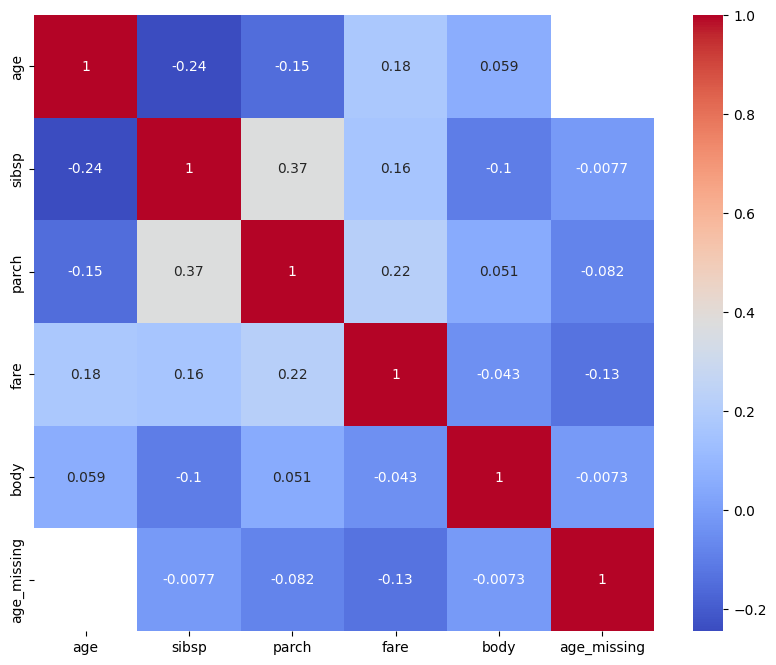

In [20]:
corr = titanic_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')


# Observations
**Passanger profile**

*   Male: 64%, Female: 36%
*   Class 3 was the biggest class with 54% passangers
*   70% of the passangers boarded in Southampton
*   Median age was 30 and the distribution is close to normal
*   Fare distribution is extremely skewed and requires log transformation



**Survival**
*   500 survived of total 1309 passangers. Survival rate depended on sex and passanger class, with females and first class passangers more likely to survive.
*   Interestingly the correlation of survival with age is lower. But fare has higher correlation with survival, which must be correlated with the Passanger class. Both Pearson and Spearman coefficients indicate to similar trend.

**Missing Data**
*   A value is "missing" (null) for approximately 90% of the passengers because their bodies were either never recovered or they survived.
*   Other features with missing data are cabin and boat. Since boat variable would be present for all survived passangers (assuming survived used lifeboats), this should not be used for prediction as it is leaky variable.
*   Missing data for age could be because of recording bias. It could be imputed.
*   Missing data for Home destination is higher for lower classes. So this is Missing Not at Random (MNAR)



## 2. LendingClub: Distributions & Loan Status
### Data overview

In [21]:
print(lending_df.shape)
display(lending_df.head())
print(lending_df.info())
display(lending_df.describe())
display(lending_df.describe(include='object'))


(9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


C:\Users\samik\AppData\Local\Temp\ipykernel_16468\4275298985.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(lending_df.describe(include='object'))


,purpose
count,9578
unique,7
top,debt_consolidation
freq,3957


### Missing Values

In [22]:
lending_df.isnull().mean().sort_values(ascending=False)


credit.policy        0.0
purpose              0.0
int.rate             0.0
installment          0.0
log.annual.inc       0.0
dti                  0.0
fico                 0.0
days.with.cr.line    0.0
revol.bal            0.0
revol.util           0.0
inq.last.6mths       0.0
delinq.2yrs          0.0
pub.rec              0.0
not.fully.paid       0.0
dtype: float64

### Target Variable analysis

not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64

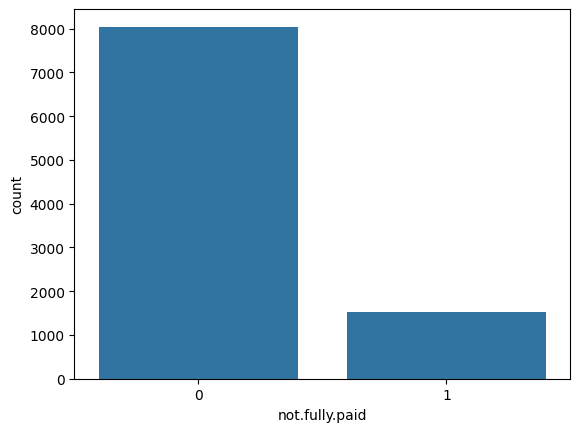

In [23]:
sns.countplot(x='not.fully.paid', data=lending_df)
lending_df['not.fully.paid'].value_counts(normalize=True)

Distributions and Univariate Analysis

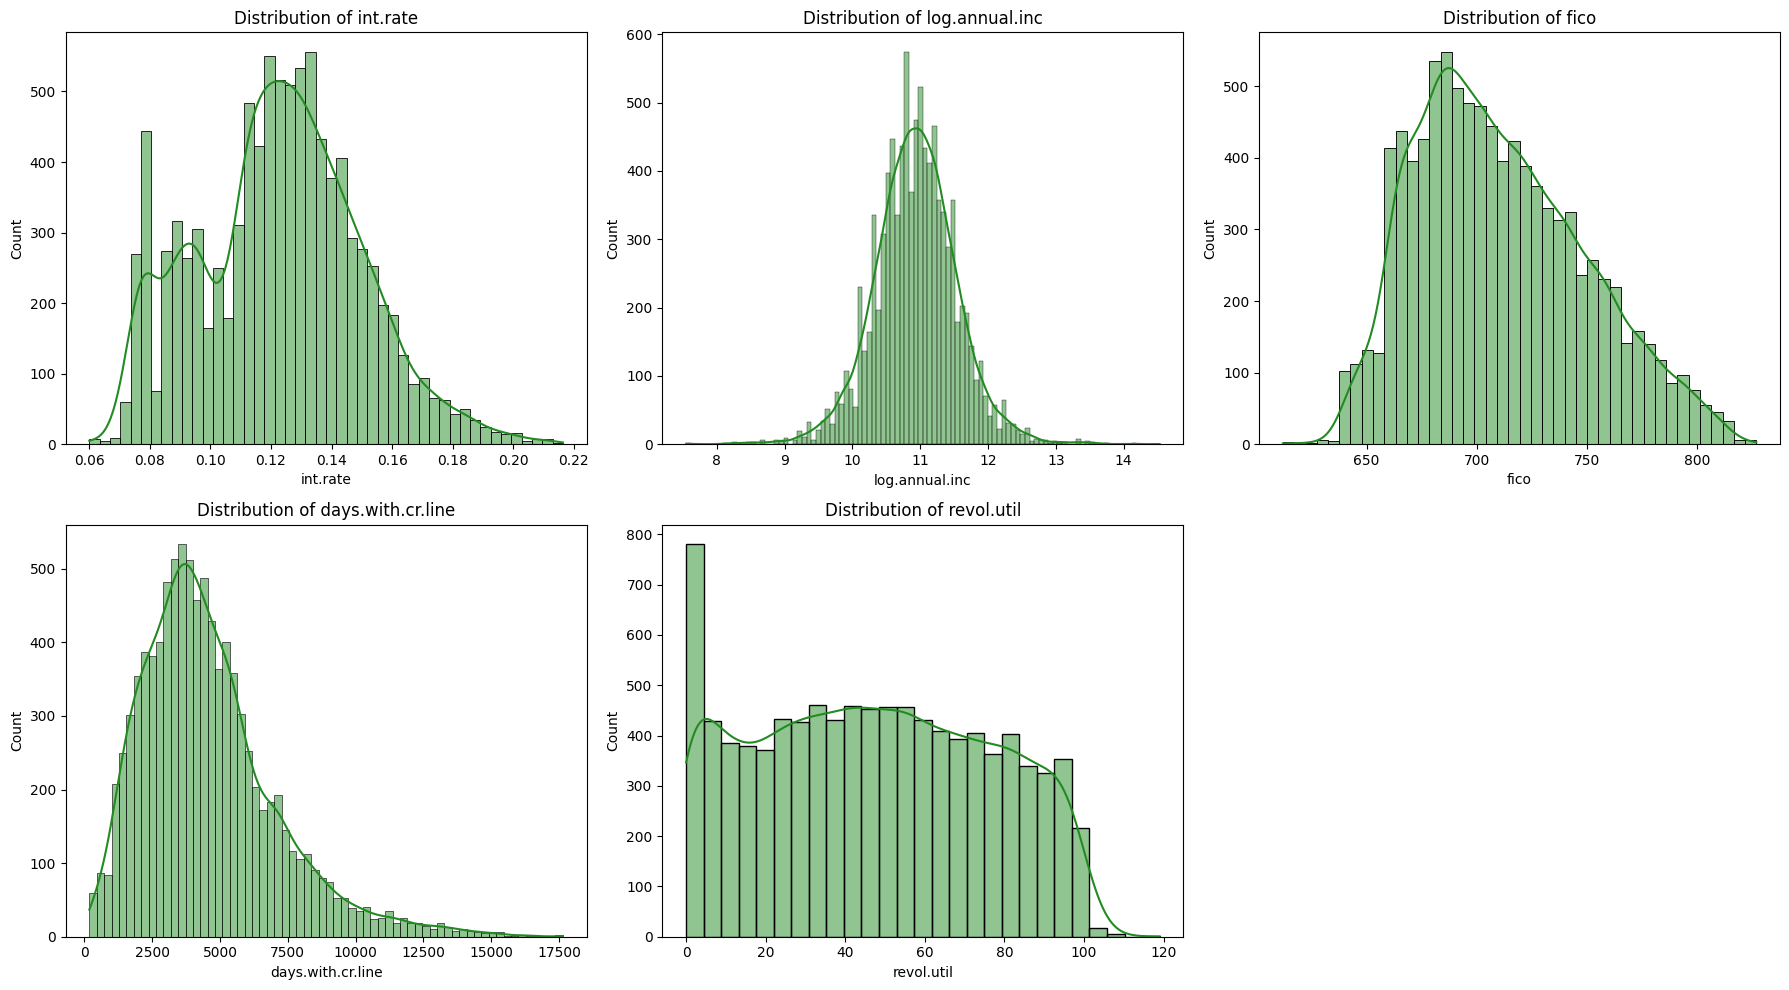

In [24]:
# List of columns to visualize
cols_to_plot = ['int.rate', 'log.annual.inc', 'fico', 'days.with.cr.line', 'revol.util']

# Create a grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(lending_df[col], kde=True, ax=axes[i], color='forestgreen')
    axes[i].set_title(f'Distribution of {col}')

# Hide the unused last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Value counts for categorical columns in LendingClub
cat_cols = ['credit.policy', 'purpose', 'not.fully.paid']

for col in cat_cols:
    print(f"--- Analysis for {col} ---")
    counts = lending_df[col].value_counts(dropna=True, normalize=True)

    if len(counts) > 5:
        top_5 = counts.nlargest(5)
        others_count = counts.iloc[5:].sum()
        res = pd.concat([top_5, pd.Series({'Others': others_count})])
        print("Top Counts (Normalized):")
        print(res)
    else:
        print("Counts (Normalized):")
        print(counts)
    print("\n")

--- Analysis for credit.policy ---
Counts (Normalized):
credit.policy
1    0.80497
0    0.19503
Name: proportion, dtype: float64


--- Analysis for purpose ---
Top Counts (Normalized):
debt_consolidation    0.413134
all_other             0.243370
credit_card           0.131760
home_improvement      0.065671
small_business        0.064627
Others                0.081437
dtype: float64


--- Analysis for not.fully.paid ---
Counts (Normalized):
not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64




### Multivariate Analysis

<Axes: xlabel='purpose', ylabel='fico'>

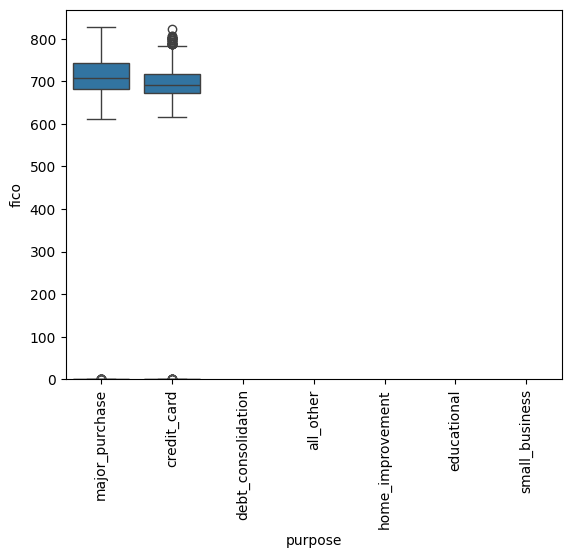

In [26]:
# FICO vs default
sns.boxplot(x='not.fully.paid', y='fico', data=lending_df)

# Interest rate vs default
sns.boxplot(x='not.fully.paid', y='int.rate', data=lending_df)

# Purpose vs default
lending_df.groupby('purpose')['not.fully.paid'].mean().sort_values().plot(kind='bar')

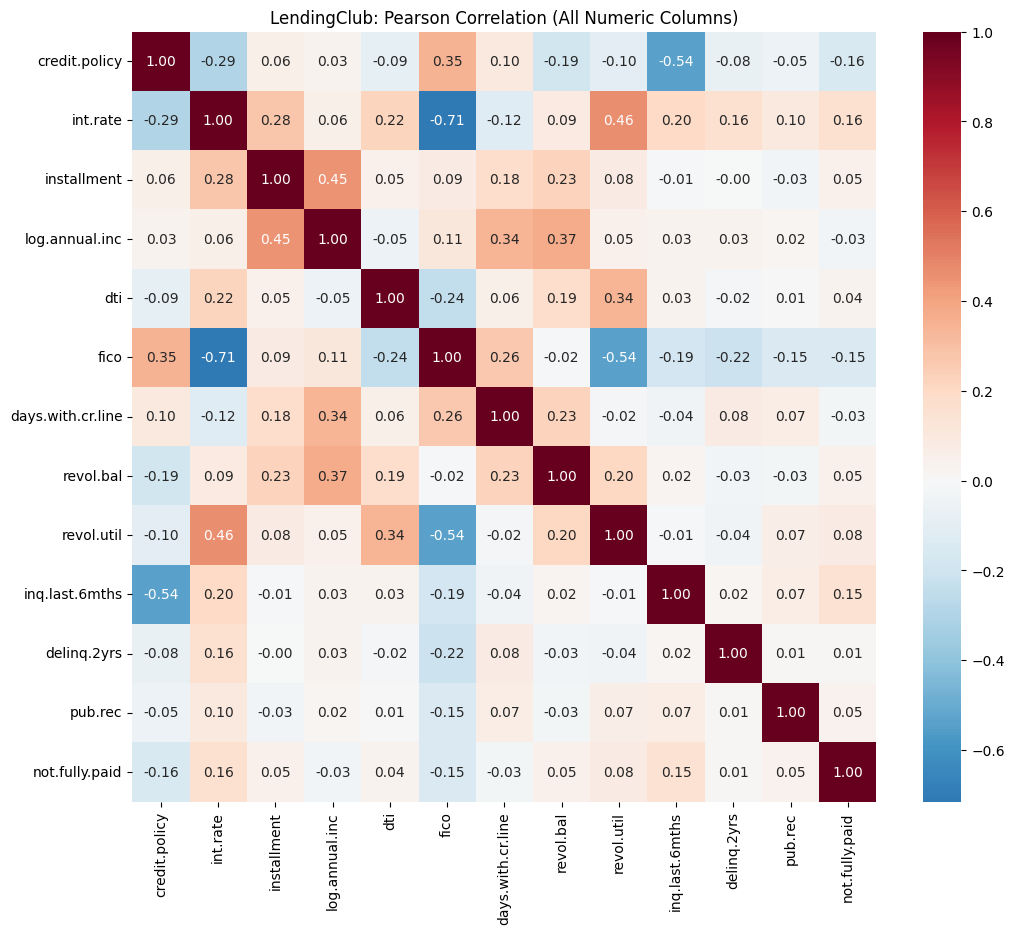

In [27]:
# Selecting all numerical columns for correlation in LendingClub
lending_numeric = lending_df.select_dtypes(include=[np.number])

corr_p = lending_numeric.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_p, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('LendingClub: Pearson Correlation (All Numeric Columns)')
plt.show()

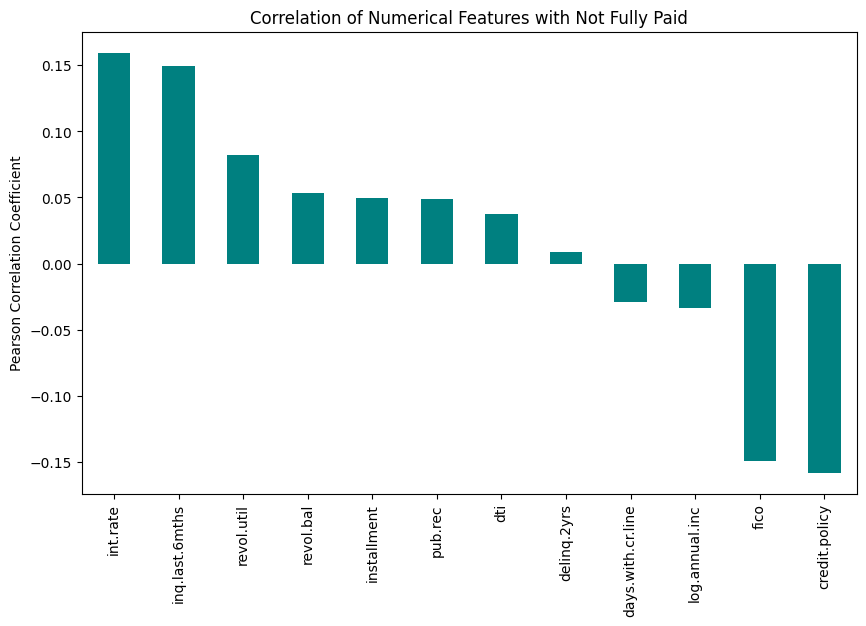

Correlations with target (not.fully.paid):
not.fully.paid       1.000000
int.rate             0.159552
inq.last.6mths       0.149452
revol.util           0.082088
revol.bal            0.053699
installment          0.049955
pub.rec              0.048634
dti                  0.037362
delinq.2yrs          0.008881
days.with.cr.line   -0.029237
log.annual.inc      -0.033439
fico                -0.149666
credit.policy       -0.158119
Name: not.fully.paid, dtype: float64


In [28]:
# Correlation of target variable 'not.fully.paid' with other numerical variables
target_corr = lending_numeric.corr()['not.fully.paid'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr.drop('not.fully.paid').plot(kind='bar', color='teal')
plt.title('Correlation of Numerical Features with Not Fully Paid')
plt.ylabel('Pearson Correlation Coefficient')
plt.show()

print("Correlations with target (not.fully.paid):")
print(target_corr)

### Segments

In [31]:
# Create FICO bands
lending_df['fico_band'] = pd.cut(
    lending_df['fico'],
    bins=[300, 600, 700, 800, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)
print(lending_df.groupby('fico_band')['not.fully.paid'].mean())
print(lending_df.groupby('purpose')['not.fully.paid'].mean())

fico_band
Fair         0.207060
Good         0.124520
Excellent    0.068966
Name: not.fully.paid, dtype: float64
purpose
all_other             0.166023
credit_card           0.115689
debt_consolidation    0.152388
educational           0.201166
home_improvement      0.170111
major_purchase        0.112128
small_business        0.277868
Name: not.fully.paid, dtype: float64


# Observations: LendingClub

**Loan Profile**
* **Interest Rates**: Typically range from 5% to 25%, showing a multi-modal distribution.
* **Correlations**: Strong positive correlation between `loan_amnt` and `installment`, as expected.
* **Status**: The majority of loans are 'Current' or 'Fully Paid', but there is a notable portion of 'Charged Off' or 'Late' loans.

### Detailed Observations: LendingClub

**Loan & Borrower Profile**
* **Risk Pricing**: Interest rates show a strong multi-modal distribution, heavily influenced by credit scores. Borrowers with higher FICO scores consistently receive lower interest rates (correlation ~ -0.71).
* **Debt Consolidation**: This is the primary driver for loans (over 41%), followed by credit card refinancing. Small business loans, while less frequent, often represent higher individual risk profiles.
* **Financial Health**: There is a clear relationship between credit utilization (`revol.util`) and FICO scores, where high utilization negatively impacts the borrower's credit rating.

**Correlation with Defaults (`not.fully.paid`)**
* **Primary Predictors**: The strongest indicators of a loan not being fully paid are higher **interest rates** and a higher number of **recent credit inquiries**. This suggests that borrowers seeking credit frequently or those assigned high-risk rates are more likely to default.
* **Protective Factors**: Meeting the internal **credit policy** and having a high **FICO score** are the strongest negative correlates with default, validating the underwriting process.
* **Weak Correlations**: Interestingly, variables like `delinq.2yrs` (past delinquencies) and `days.with.cr.line` show very weak direct correlations with the target compared to real-time credit metrics.

**Data Quality & Imbalance**
* **Class Imbalance**: The dataset is imbalanced, with only ~16% of loans not being fully paid. Any future predictive modeling will need to account for this to avoid bias toward the majority 'paid' class.
* **Completeness**: Unlike the Titanic dataset, the LendingClub data from OpenML is highly structured with very few missing values in the numerical features, making it suitable for direct correlation analysis.